# Solar Filament Segmentation Challenge 2026

- **Autore:** Francesco Peluso [`IE22700088` | f.peluso29@studenti.unisa.it]
- **Corso:** Machine Learning A.A. 2025/26 — Laurea Magistrale in Ingegneria Informatica, DIEM, Università degli Studi di Salerno

## Descrizione del problema

L'obiettivo è identificare i filamenti nelle immagini solari formulando il problema come **segmentazione semantica binaria**: ogni pixel deve essere classificato come sfondo (0) o filamento (1). I filamenti sono strutture sottili e irregolari, spesso poco contrastate rispetto alla superficie solare; inoltre, occupano una porzione ridotta dell'immagine e producono un forte sbilanciamento tra le classi.

La qualità della segmentazione sarà valutata principalmente con il **coefficiente di Dice**, che misura la sovrapposizione tra la maschera predetta $P$ e la ground truth $G$:

$$
\mathrm{Dice}(P,G)=\frac{2|P\cap G|}{|P|+|G|}.
$$

## Approccio proposto

Come punto di partenza useremo una **U-Net**. L'encoder estrae caratteristiche progressivamente più astratte, il decoder ricostruisce la mappa di segmentazione e le *skip connections* trasferiscono informazioni spaziali ad alta risoluzione. Queste ultime sono particolarmente utili per preservare forma, contorni e continuità dei filamenti più sottili. L'uscita avrà un solo canale e sarà convertita in probabilità mediante una funzione sigmoide.

## Caricamento del dataset

Le annotazioni sono memorizzate in formato COCO: ogni record in `images` identifica un'annotazione indipendente di una determinata osservazione, mentre `annotations` contiene i poligoni dei singoli filamenti. Poiché la stessa immagine può essere stata annotata da più annotatori, un file JPEG può comparire con più `image_id`. Conserviamo queste ground truth come campioni distinti, ma effettuiamo lo split per **nome del file**, così la stessa osservazione non può comparire in partizioni diverse.

In [1]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

SEED = 22
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15

# Funziona sia avviando Jupyter dalla root, sia da una sua sottocartella.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "dataset").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Cartella 'dataset' non trovata nella directory corrente o nei suoi parent.")

TRAIN_DIR = PROJECT_ROOT / "dataset" / "train"
TRAIN_IMAGES_DIR = TRAIN_DIR / "train_images"
ANNOTATIONS_PATH = TRAIN_DIR / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
OFFICIAL_TEST_IMAGES_DIR = PROJECT_ROOT / "dataset" / "test" / "test_images"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/fp/GitHub Repos/MachineLearning-Project


In [2]:
with ANNOTATIONS_PATH.open(encoding="utf-8") as file:
    coco = json.load(file)

annotations_by_image_id = defaultdict(list)
for annotation in coco["annotations"]:
    annotations_by_image_id[annotation["image_id"]].append(annotation)

samples = []
for image_info in coco["images"]:
    image_path = TRAIN_IMAGES_DIR / image_info["file_name"]
    samples.append(
        {
            "image_id": image_info["id"],
            "file_name": image_info["file_name"],
            "image_path": image_path,
            "width": image_info["width"],
            "height": image_info["height"],
            "annotations": annotations_by_image_id[image_info["id"]],
        }
    )

missing_images = [sample["image_path"] for sample in samples if not sample["image_path"].is_file()]
if missing_images:
    raise FileNotFoundError(f"Mancano {len(missing_images)} immagini; prima: {missing_images[0]}")

records_per_file = Counter(sample["file_name"] for sample in samples)
official_test_count = len(list(OFFICIAL_TEST_IMAGES_DIR.glob("*.jpeg")))

print(f"File JPEG annotati univoci: {len(records_per_file)}")
print(f"Record COCO (immagine + annotatore): {len(samples)}")
print(f"Poligoni di filamenti: {len(coco['annotations'])}")
print(f"Record per file: {dict(sorted(Counter(records_per_file.values()).items()))}")
print(f"Immagini del test ufficiale Kaggle, senza ground truth: {official_test_count}")

File JPEG annotati univoci: 707
Record COCO (immagine + annotatore): 1154
Poligoni di filamenti: 8199
Record per file: {1: 411, 2: 145, 3: 151}
Immagini del test ufficiale Kaggle, senza ground truth: 180


## Split in training, validation e test

Dividiamo le 707 osservazioni annotate in modo riproducibile nelle proporzioni **70% / 15% / 15%**. Questo test set interno serve per la valutazione finale del modello e non va confuso con `dataset/test/test_images`, che è il test ufficiale Kaggle privo di ground truth. Tutti i record prodotti da annotatori diversi per la stessa immagine rimangono nella medesima partizione.

In [3]:
def split_samples_by_file(
    samples,
    train_fraction=TRAIN_FRACTION,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
):
    if not 0 < train_fraction < 1 or not 0 < validation_fraction < 1:
        raise ValueError("Le frazioni devono essere comprese tra 0 e 1.")
    if train_fraction + validation_fraction >= 1:
        raise ValueError("La somma delle frazioni di training e validation deve essere minore di 1.")

    file_names = sorted({sample["file_name"] for sample in samples})
    random.Random(seed).shuffle(file_names)

    train_end = int(len(file_names) * train_fraction)
    validation_end = train_end + int(len(file_names) * validation_fraction)
    file_names_by_split = {
        "train": set(file_names[:train_end]),
        "validation": set(file_names[train_end:validation_end]),
        "test": set(file_names[validation_end:]),
    }

    samples_by_split = {
        split_name: [sample for sample in samples if sample["file_name"] in split_file_names]
        for split_name, split_file_names in file_names_by_split.items()
    }
    return samples_by_split, file_names_by_split


samples_by_split, file_names_by_split = split_samples_by_file(samples)

assert file_names_by_split["train"].isdisjoint(file_names_by_split["validation"])
assert file_names_by_split["train"].isdisjoint(file_names_by_split["test"])
assert file_names_by_split["validation"].isdisjoint(file_names_by_split["test"])
assert sum(map(len, file_names_by_split.values())) == len({s["file_name"] for s in samples})

for split_name in ("train", "validation", "test"):
    n_files = len(file_names_by_split[split_name])
    n_records = len(samples_by_split[split_name])
    n_polygons = sum(len(sample["annotations"]) for sample in samples_by_split[split_name])
    print(f"{split_name:10s}: {n_files:3d} file, {n_records:3d} record COCO, {n_polygons:4d} poligoni")

train     : 494 file, 806 record COCO, 5856 poligoni
validation: 106 file, 169 record COCO, 1144 poligoni
test      : 107 file, 179 record COCO, 1199 poligoni


## Costruzione delle maschere binarie

Ogni annotazione descrive un filamento mediante uno o più poligoni COCO. La funzione seguente rasterizza tutti i poligoni associati a un `image_id` in una singola maschera binaria. Immagini e maschere vengono caricate **on demand**, evitando di conservare in RAM l'intero dataset ad alta risoluzione.

Esempio: 20140609195854Bh.jpeg (040301-20140609195854Bh)
Immagine: shape=(2048, 2048, 3), dtype=uint8
Maschera:  shape=(2048, 2048), dtype=uint8, valori=[0 1]
Pixel di filamento: 18,170


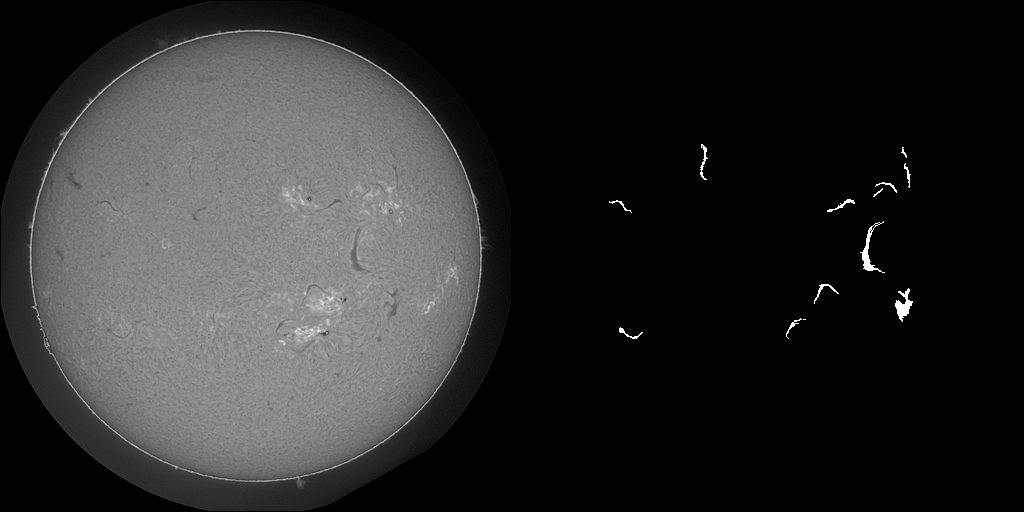

In [4]:
def annotations_to_binary_mask(width, height, annotations):
    mask = Image.new("L", (width, height), 0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        for polygon in annotation.get("segmentation", []):
            if len(polygon) < 6:
                continue
            points = [(polygon[index], polygon[index + 1]) for index in range(0, len(polygon), 2)]
            drawer.polygon(points, fill=1)

    return np.asarray(mask, dtype=np.uint8)


def load_sample(sample):
    with Image.open(sample["image_path"]) as image_file:
        image = np.asarray(image_file.convert("RGB"))

    mask = annotations_to_binary_mask(
        width=sample["width"],
        height=sample["height"],
        annotations=sample["annotations"],
    )
    if image.shape[:2] != mask.shape:
        raise ValueError(f"Dimensioni non coerenti per {sample['file_name']}: {image.shape[:2]} != {mask.shape}")
    return image, mask


example_sample = samples_by_split["train"][0]
example_image, example_mask = load_sample(example_sample)

print(f"Esempio: {example_sample['file_name']} ({example_sample['image_id']})")
print(f"Immagine: shape={example_image.shape}, dtype={example_image.dtype}")
print(f"Maschera:  shape={example_mask.shape}, dtype={example_mask.dtype}, valori={np.unique(example_mask)}")
print(f"Pixel di filamento: {example_mask.sum():,}")

# Visualizzazione affiancata dell'immagine e della relativa ground truth.
preview_size = (512, 512)
image_preview = Image.fromarray(example_image).resize(preview_size)
mask_preview = Image.fromarray(example_mask * 255).resize(preview_size, resample=Image.Resampling.NEAREST)
side_by_side_preview = Image.new("RGB", (preview_size[0] * 2, preview_size[1]))
side_by_side_preview.paste(image_preview, (0, 0))
side_by_side_preview.paste(mask_preview.convert("RGB"), (preview_size[0], 0))
side_by_side_preview  # Jupyter visualizza automaticamente l'ultima espressione della cella.

## Pipeline PyTorch

Le osservazioni H-alpha sono immagini in scala di grigi. Per questa prima baseline le ridimensioniamo a $512\times512$ pixel e produciamo tensori con forma `1 × H × W`. Durante il training applichiamo rotazioni di multipli di 90° e riflessioni sia all'immagine sia alla maschera; validation e test ricevono soltanto resize e normalizzazione in $[0,1]$. Il resize della maschera usa sempre l'interpolazione nearest-neighbor per non introdurre valori intermedi nelle classi.

In [5]:
import csv
import platform
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import ImageOps
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

IMAGE_SIZE = (512, 512)
BATCH_SIZE = 2
NUM_WORKERS = 0  # Impostazione portabile per l'esecuzione dentro Jupyter.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch: {torch.__version__} | Device: {device}")

PyTorch: 2.12.0 | Device: mps


/opt/anaconda3/envs/ML/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
class SegmentationTransform:
    def __init__(self, size=IMAGE_SIZE, augment=False):
        self.size = size
        self.augment = augment

    def __call__(self, image, mask):
        # Le JPEG H-alpha sono monocromatiche; manteniamo un solo canale.
        image = Image.fromarray(image).convert("L")
        mask = Image.fromarray(mask)

        # PIL usa (larghezza, altezza), mentre IMAGE_SIZE è (altezza, larghezza).
        resize_size = (self.size[1], self.size[0])
        image = image.resize(resize_size, resample=Image.Resampling.BILINEAR)
        mask = mask.resize(resize_size, resample=Image.Resampling.NEAREST)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                image = ImageOps.mirror(image)
                mask = ImageOps.mirror(mask)
            if torch.rand(1).item() < 0.5:
                image = ImageOps.flip(image)
                mask = ImageOps.flip(mask)

            rotation = int(torch.randint(0, 4, (1,)).item())
            rotation_ops = (
                None,
                Image.Transpose.ROTATE_90,
                Image.Transpose.ROTATE_180,
                Image.Transpose.ROTATE_270,
            )
            if rotation_ops[rotation] is not None:
                image = image.transpose(rotation_ops[rotation])
                mask = mask.transpose(rotation_ops[rotation])

        image_array = np.array(image, dtype=np.float32, copy=True) / 255.0
        mask_array = np.array(mask, dtype=np.float32, copy=True)
        mask_array = (mask_array > 0).astype(np.float32)

        image_tensor = torch.from_numpy(image_array).unsqueeze(0)
        mask_tensor = torch.from_numpy(mask_array).unsqueeze(0)
        return image_tensor, mask_tensor


class SolarFilamentDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image, mask = load_sample(sample)
        image, mask = self.transform(image, mask)
        return {
            "image": image,
            "mask": mask,
            "file_name": sample["file_name"],
            "image_id": sample["image_id"],
        }

In [7]:
train_dataset = SolarFilamentDataset(
    samples_by_split["train"],
    transform=SegmentationTransform(augment=True),
)
validation_dataset = SolarFilamentDataset(
    samples_by_split["validation"],
    transform=SegmentationTransform(augment=False),
)
test_dataset = SolarFilamentDataset(
    samples_by_split["test"],
    transform=SegmentationTransform(augment=False),
)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

example_batch = next(iter(train_loader))
print(f"Batch immagini: {tuple(example_batch['image'].shape)}")
print(f"Batch maschere: {tuple(example_batch['mask'].shape)}")
print(f"Valori maschera: {torch.unique(example_batch['mask']).tolist()}")

Batch immagini: (2, 1, 512, 512)
Batch maschere: (2, 1, 512, 512)
Valori maschera: [0.0, 1.0]


## U-Net baseline

La rete seguente usa quattro livelli encoder–decoder e 16 filtri nel primo livello. È volutamente compatta per ottenere rapidamente una baseline e contenere l'uso di memoria. L'ultimo strato restituisce i **logit**: la sigmoide viene applicata dalla loss o in fase di inferenza, non dentro `forward`.

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat((skip, x), dim=1))


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c = base_channels
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder_1 = DoubleConv(in_channels, c)
        self.encoder_2 = DoubleConv(c, c * 2)
        self.encoder_3 = DoubleConv(c * 2, c * 4)
        self.encoder_4 = DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)
        self.decoder_4 = DecoderBlock(c * 16, c * 8, c * 8)
        self.decoder_3 = DecoderBlock(c * 8, c * 4, c * 4)
        self.decoder_2 = DecoderBlock(c * 4, c * 2, c * 2)
        self.decoder_1 = DecoderBlock(c * 2, c, c)
        self.output = nn.Conv2d(c, out_channels, kernel_size=1)

    def forward(self, x):
        skip_1 = self.encoder_1(x)
        skip_2 = self.encoder_2(self.pool(skip_1))
        skip_3 = self.encoder_3(self.pool(skip_2))
        skip_4 = self.encoder_4(self.pool(skip_3))
        x = self.bottleneck(self.pool(skip_4))
        x = self.decoder_4(x, skip_4)
        x = self.decoder_3(x, skip_3)
        x = self.decoder_2(x, skip_2)
        x = self.decoder_1(x, skip_1)
        return self.output(x)

## Loss e metrica

Per gestire lo sbilanciamento tra sfondo e filamenti combiniamo `BCEWithLogitsLoss`, stabile numericamente, e **soft Dice loss**. Per il monitoraggio riportiamo invece il Dice sulle maschere binarie ottenute con soglia 0,5.

In [9]:
def soft_dice_score(logits, targets, epsilon=1e-6):
    probabilities = torch.sigmoid(logits)
    dimensions = (1, 2, 3)
    intersection = (probabilities * targets).sum(dim=dimensions)
    denominator = probabilities.sum(dim=dimensions) + targets.sum(dim=dimensions)
    return ((2.0 * intersection + epsilon) / (denominator + epsilon)).mean()


def binary_dice_score(logits, targets, threshold=0.5, epsilon=1e-6):
    predictions = (torch.sigmoid(logits) >= threshold).float()
    dimensions = (1, 2, 3)
    intersection = (predictions * targets).sum(dim=dimensions)
    denominator = predictions.sum(dim=dimensions) + targets.sum(dim=dimensions)
    return ((2.0 * intersection + epsilon) / (denominator + epsilon)).mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = 1.0 - soft_dice_score(logits, targets)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


model = UNet().to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
with torch.no_grad():
    sanity_images = example_batch["image"].to(device)
    sanity_masks = example_batch["mask"].to(device)
    sanity_logits = model(sanity_images)
    sanity_loss = criterion(sanity_logits, sanity_masks)

print(f"Parametri addestrabili: {parameter_count:,}")
print(f"Output U-Net: {tuple(sanity_logits.shape)}")
print(f"Loss iniziale: {sanity_loss.item():.4f}")

Parametri addestrabili: 1,942,289
Output U-Net: (2, 1, 512, 512)
Loss iniziale: 0.8759


## Tracciamento dell'esperimento

Ogni configurazione usa una cartella dedicata in `experiments/`. Prima di avviare un nuovo esperimento occorre cambiare `EXPERIMENT_ID`; rieseguire lo stesso ID aggiorna i file della medesima esecuzione. Cronologia e checkpoint migliore vengono salvati durante il training, così i risultati già completati sopravvivono anche a un'interruzione.

In [ ]:
EXPERIMENT_ID = "01"
EPOCHS = 20
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / EXPERIMENT_ID
METRICS_DIR = EXPERIMENT_DIR / "metrics"
PLOTS_DIR = EXPERIMENT_DIR / "plots"
CHECKPOINTS_DIR = EXPERIMENT_DIR / "checkpoints"

for directory in (EXPERIMENT_DIR, METRICS_DIR, PLOTS_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def save_json(data, path):
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")


def save_history(history, metrics_dir=METRICS_DIR):
    save_json(history, metrics_dir / "history.json")
    if history:
        with (metrics_dir / "history.csv").open("w", newline="", encoding="utf-8") as file:
            writer = csv.DictWriter(file, fieldnames=history[0].keys())
            writer.writeheader()
            writer.writerows(history)


experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "model": "UNet from scratch",
    "in_channels": 1,
    "base_channels": 16,
    "trainable_parameters": parameter_count,
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "optimizer": "AdamW",
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "loss": "0.5 * BCEWithLogitsLoss + 0.5 * DiceLoss",
    "seed": SEED,
    "split_fractions": {"train": TRAIN_FRACTION, "validation": VALIDATION_FRACTION, "test": 1 - TRAIN_FRACTION - VALIDATION_FRACTION},
    "unique_files_per_split": {name: len(files) for name, files in file_names_by_split.items()},
    "coco_records_per_split": {name: len(records) for name, records in samples_by_split.items()},
    "device": str(device),
    "python_version": sys.version.split()[0],
    "pytorch_version": torch.__version__,
    "platform": platform.platform(),
}
save_json(experiment_config, EXPERIMENT_DIR / "config.json")
save_json(
    {name: sorted(files) for name, files in file_names_by_split.items()},
    EXPERIMENT_DIR / "split_manifest.json",
)
(EXPERIMENT_DIR / "model.txt").write_text(str(model), encoding="utf-8")
print(f"Artefatti dell'esperimento: {EXPERIMENT_DIR}")

## Ciclo di addestramento

Il ciclo salva in memoria i pesi corrispondenti al Dice di validation migliore e li ripristina al termine. `RUN_TRAINING` è inizialmente `False`: dopo aver verificato il sanity check precedente, impostarlo a `True` per avviare il training.

In [10]:
def run_epoch(model, data_loader, criterion, device, optimizer=None, description=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_dice = 0.0
    total_samples = 0

    progress_bar = tqdm(
        data_loader,
        desc=description or ("Training" if is_training else "Validation"),
        unit="batch",
        leave=False,
    )
    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, masks)
            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        batch_dice = binary_dice_score(logits.detach(), masks).item()
        total_dice += batch_dice * batch_size
        total_samples += batch_size
        progress_bar.set_postfix(
            loss=f"{total_loss / total_samples:.4f}",
            dice=f"{total_dice / total_samples:.4f}",
        )

    return {
        "loss": total_loss / total_samples,
        "dice": total_dice / total_samples,
    }


def fit(model, train_loader, validation_loader, criterion, optimizer, device, epochs, experiment_dir):
    history = []
    best_validation_dice = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            device,
            optimizer,
            description=f"Epoca {epoch:02d}/{epochs} [train]",
        )
        with torch.no_grad():
            validation_metrics = run_epoch(
                model,
                validation_loader,
                criterion,
                device,
                description=f"Epoca {epoch:02d}/{epochs} [validation]",
            )

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "validation_loss": validation_metrics["loss"],
            "validation_dice": validation_metrics["dice"],
        })
        save_history(history, experiment_dir / "metrics")

        if validation_metrics["dice"] > best_validation_dice:
            best_validation_dice = validation_metrics["dice"]
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "validation_loss": validation_metrics["loss"],
                    "validation_dice": validation_metrics["dice"],
                    "experiment_id": experiment_dir.name,
                },
                experiment_dir / "checkpoints" / "best_model.pt",
            )
            save_json(
                {"best_epoch": epoch, "best_validation_dice": best_validation_dice},
                experiment_dir / "metrics" / "best_validation.json",
            )

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f}, Dice {train_metrics['dice']:.4f} | "
            f"val loss {validation_metrics['loss']:.4f}, Dice {validation_metrics['dice']:.4f}"
        )

    model.load_state_dict(best_state)
    print(f"Miglior Dice di validation: {best_validation_dice:.4f}")
    return history


RUN_TRAINING = True

if RUN_TRAINING:
    history = fit(
        model,
        train_loader,
        validation_loader,
        criterion,
        optimizer,
        device,
        epochs=EPOCHS,
        experiment_dir=EXPERIMENT_DIR,
    )
else:
    history = None
    print("Training non avviato: impostare RUN_TRAINING = True quando si è pronti.")

Epoch 01/20 | train loss 0.5989, Dice 0.1830 | val loss 0.4991, Dice 0.3226


Epoch 02/20 | train loss 0.3634, Dice 0.5033 | val loss 0.2409, Dice 0.5885


Epoch 03/20 | train loss 0.2375, Dice 0.5683 | val loss 0.2200, Dice 0.5930


Epoch 04/20 | train loss 0.2136, Dice 0.6013 | val loss 0.2545, Dice 0.5176


Epoch 05/20 | train loss 0.2134, Dice 0.5995 | val loss 0.1961, Dice 0.6303


...

Epoch 16/20 | train loss 0.1936, Dice 0.6330 | val loss 0.2074, Dice 0.6033


Epoch 17/20 | train loss 0.1917, Dice 0.6363 | val loss 0.2361, Dice 0.5500


Epoch 18/20 | train loss 0.1904, Dice 0.6388 | val loss 0.2021, Dice 0.6151


Epoch 19/20 | train loss 0.1910, Dice 0.6378 | val loss 0.1968, Dice 0.6256


Epoch 20/20 | train loss 0.1877, Dice 0.6443 | val loss 0.1886, Dice 0.6415
Miglior Dice di validation: 0.6415


## Controlli dell'addestramento

Le celle seguenti vengono eseguite soltanto se esiste `history`, quindi un normale *Run all* con `RUN_TRAINING = False` non produce errori. Controlliamo l'andamento di loss e Dice per individuare underfitting o overfitting.

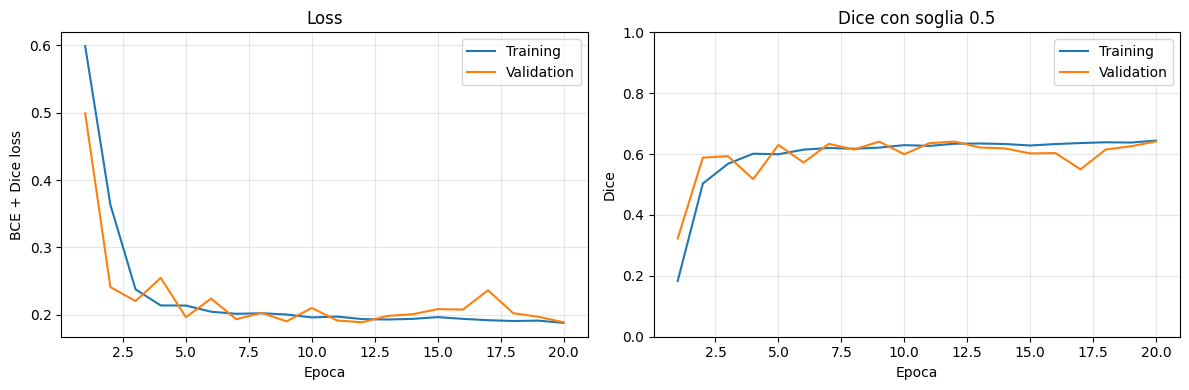

In [11]:
def plot_training_history(history, save_path=None):
    import matplotlib.pyplot as plt

    epochs = [row["epoch"] for row in history]
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, [row["train_loss"] for row in history], label="Training")
    axes[0].plot(epochs, [row["validation_loss"] for row in history], label="Validation")
    axes[0].set(title="Loss", xlabel="Epoca", ylabel="BCE + Dice loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_dice"] for row in history], label="Training")
    axes[1].plot(epochs, [row["validation_dice"] for row in history], label="Validation")
    axes[1].set(title="Dice con soglia 0.5", xlabel="Epoca", ylabel="Dice", ylim=(0, 1))
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    figure.tight_layout()
    if save_path is not None:
        figure.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


if "history" in globals() and history:
    plot_training_history(history, PLOTS_DIR / "training_curves.png")
else:
    print("Curve non disponibili: eseguire prima il training.")

## Controllo qualitativo sulla validation

Confrontiamo immagine, ground truth, probabilità e maschera predetta. Questa visualizzazione usa esclusivamente campioni di validation e mostra anche il Dice del singolo campione.

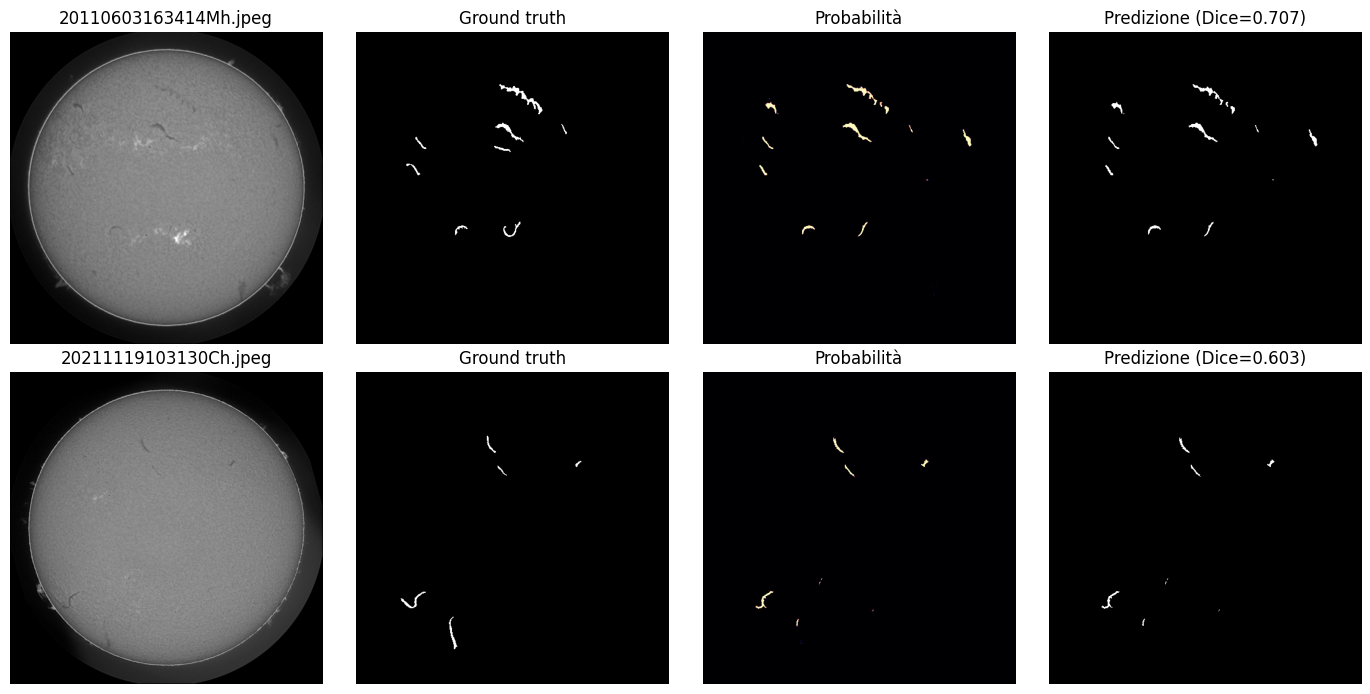

In [12]:
@torch.inference_mode()
def get_prediction_batch(model, data_loader, device):
    model.eval()
    batch = next(iter(data_loader))
    images = batch["image"].to(device)
    logits = model(images)
    return {
        "images": batch["image"].cpu(),
        "masks": batch["mask"].cpu(),
        "probabilities": torch.sigmoid(logits).cpu(),
        "file_names": batch["file_name"],
    }


def show_segmentation_predictions(prediction_batch, threshold=0.5, max_samples=2, save_path=None):
    import matplotlib.pyplot as plt

    sample_count = min(max_samples, len(prediction_batch["file_names"]))
    figure, axes = plt.subplots(sample_count, 4, figsize=(14, 3.5 * sample_count), squeeze=False)

    for row in range(sample_count):
        image = prediction_batch["images"][row, 0].numpy()
        target = prediction_batch["masks"][row, 0].numpy()
        probability = prediction_batch["probabilities"][row, 0].numpy()
        prediction = (probability >= threshold).astype(np.uint8)
        intersection = (prediction * target).sum()
        dice = (2 * intersection + 1e-6) / (prediction.sum() + target.sum() + 1e-6)

        axes[row, 0].imshow(image, cmap="gray", vmin=0, vmax=1)
        axes[row, 0].set_title(prediction_batch["file_names"][row])
        axes[row, 1].imshow(target, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(probability, cmap="magma", vmin=0, vmax=1)
        axes[row, 2].set_title("Probabilità")
        axes[row, 3].imshow(prediction, cmap="gray", vmin=0, vmax=1)
        axes[row, 3].set_title(f"Predizione (Dice={dice:.3f})")

        for axis in axes[row]:
            axis.axis("off")

    figure.tight_layout()
    if save_path is not None:
        figure.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


if "history" in globals() and history:
    validation_prediction_batch = get_prediction_batch(model, validation_loader, device)
    show_segmentation_predictions(
        validation_prediction_batch,
        save_path=PLOTS_DIR / "validation_predictions_threshold_0.50.png",
    )
else:
    print("Predizioni non disponibili: eseguire prima il training.")

## Selezione della soglia

La soglia 0,5 non è necessariamente ottimale, soprattutto in presenza di classi sbilanciate. Cerchiamo il valore che massimizza il Dice medio tra 0,10 e 0,90 usando **soltanto la validation**. La ricerca è vettorizzata per valutare tutte le soglie con un singolo forward pass per batch.

Soglia scelta sulla validation: 0.15 (Dice=0.6462)


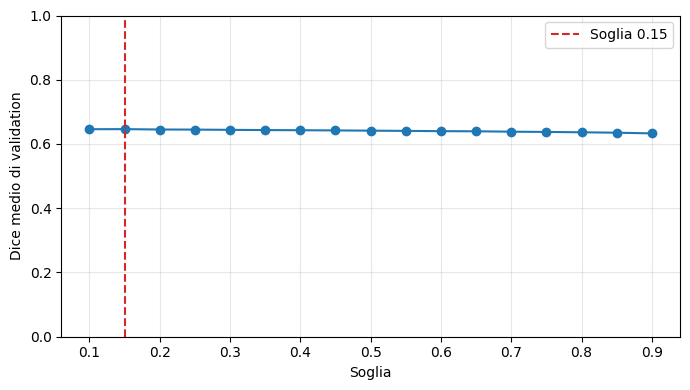

In [13]:
@torch.inference_mode()
def find_best_threshold(model, data_loader, device, thresholds=None, epsilon=1e-6):
    model.eval()
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    threshold_tensor = torch.as_tensor(thresholds, dtype=torch.float32, device=device)
    score_sums = torch.zeros_like(threshold_tensor)
    sample_count = 0

    progress_bar = tqdm(
        data_loader,
        desc="Ricerca soglia [validation]",
        unit="batch",
        leave=False,
    )
    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["mask"].to(device, non_blocking=True)
        probabilities = torch.sigmoid(model(images))

        predictions = (
            probabilities.unsqueeze(0)
            >= threshold_tensor.view(-1, 1, 1, 1, 1)
        )
        expanded_targets = targets.unsqueeze(0)
        dimensions = (2, 3, 4)
        intersection = (predictions * expanded_targets).sum(dim=dimensions)
        denominator = predictions.sum(dim=dimensions) + expanded_targets.sum(dim=dimensions)
        dice_per_sample = (2.0 * intersection + epsilon) / (denominator + epsilon)

        score_sums += dice_per_sample.sum(dim=1)
        sample_count += targets.shape[0]
        current_scores = score_sums / sample_count
        progress_bar.set_postfix(
            best_dice=f"{current_scores.max().item():.4f}",
        )

    mean_scores = score_sums / sample_count
    best_index = int(mean_scores.argmax().item())
    return {
        "thresholds": threshold_tensor.cpu().numpy(),
        "dice_scores": mean_scores.cpu().numpy(),
        "best_threshold": float(threshold_tensor[best_index].item()),
        "best_dice": float(mean_scores[best_index].item()),
    }


def plot_threshold_search(results, save_path=None):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    plt.plot(results["thresholds"], results["dice_scores"], marker="o")
    plt.axvline(results["best_threshold"], color="tab:red", linestyle="--", label=f"Soglia {results['best_threshold']:.2f}")
    plt.xlabel("Soglia")
    plt.ylabel("Dice medio di validation")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


best_threshold = 0.5
if "history" in globals() and history:
    threshold_results = find_best_threshold(model, validation_loader, device)
    best_threshold = threshold_results["best_threshold"]
    print(
        f"Soglia scelta sulla validation: {best_threshold:.2f} "
        f"(Dice={threshold_results['best_dice']:.4f})"
    )
    threshold_rows = [
        {"threshold": float(threshold), "validation_dice": float(score)}
        for threshold, score in zip(threshold_results["thresholds"], threshold_results["dice_scores"])
    ]
    save_json(
        {
            "best_threshold": threshold_results["best_threshold"],
            "best_validation_dice": threshold_results["best_dice"],
            "scores": threshold_rows,
        },
        METRICS_DIR / "threshold_search.json",
    )
    with (METRICS_DIR / "threshold_search.csv").open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=("threshold", "validation_dice"))
        writer.writeheader()
        writer.writerows(threshold_rows)
    plot_threshold_search(threshold_results, PLOTS_DIR / "threshold_search.png")
else:
    print("Ricerca non eseguita: in assenza di training resta valida la soglia predefinita 0.5.")

## Valutazione finale sul test interno

Il test interno deve essere consultato una sola volta, dopo aver concluso tutte le scelte su modello, iperparametri e soglia. Per questo motivo la valutazione è protetta dal flag `RUN_FINAL_TEST`, disattivato per impostazione predefinita.

In [14]:
@torch.inference_mode()
def evaluate_model(model, data_loader, criterion, device, threshold):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_samples = 0

    progress_bar = tqdm(
        data_loader,
        desc=f"Test interno [soglia={threshold:.2f}]",
        unit="batch",
        leave=False,
    )
    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, masks)
        dice = binary_dice_score(logits, masks, threshold=threshold)

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_dice += dice.item() * batch_size
        total_samples += batch_size
        progress_bar.set_postfix(
            loss=f"{total_loss / total_samples:.4f}",
            dice=f"{total_dice / total_samples:.4f}",
        )

    return {
        "loss": total_loss / total_samples,
        "dice": total_dice / total_samples,
        "threshold": threshold,
        "samples": total_samples,
    }


RUN_FINAL_TEST = True

if RUN_FINAL_TEST:
    if "history" not in globals() or not history:
        raise RuntimeError("Eseguire il training prima della valutazione finale.")
    test_metrics = evaluate_model(
        model,
        test_loader,
        criterion,
        device,
        threshold=best_threshold,
    )
    print(
        f"Test interno | loss={test_metrics['loss']:.4f}, "
        f"Dice={test_metrics['dice']:.4f}, soglia={test_metrics['threshold']:.2f}, "
        f"campioni={test_metrics['samples']}"
    )
    save_json(test_metrics, METRICS_DIR / "test_metrics.json")
    test_prediction_batch = get_prediction_batch(model, test_loader, device)
    show_segmentation_predictions(
        test_prediction_batch,
        threshold=best_threshold,
        save_path=PLOTS_DIR / "test_predictions.png",
    )
else:
    print("Test interno non consultato (RUN_FINAL_TEST = False).")

Test interno | loss=0.2014, Dice=0.6157, soglia=0.15, campioni=179


## Archivio dell'esperimento

Questa cella consolida il riepilogo e il checkpoint del modello migliore. Può essere eseguita anche dopo una run già conclusa, purché `model` e `history` siano ancora presenti nel kernel.

In [ ]:
if "history" in globals() and history:
    save_history(history)
    best_history_row = max(history, key=lambda row: row["validation_dice"])
    checkpoint = {
        "epoch": best_history_row["epoch"],
        "model_state_dict": {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        },
        "validation_dice": best_history_row["validation_dice"],
        "best_threshold": best_threshold,
        "experiment_id": EXPERIMENT_ID,
    }
    torch.save(checkpoint, CHECKPOINTS_DIR / "best_model.pt")

    experiment_summary = {
        "experiment_id": EXPERIMENT_ID,
        "best_epoch": best_history_row["epoch"],
        "best_validation_dice_at_0.5": best_history_row["validation_dice"],
        "selected_threshold": best_threshold,
    }
    if "threshold_results" in globals():
        experiment_summary["validation_dice_at_selected_threshold"] = threshold_results["best_dice"]
    if "test_metrics" in globals():
        experiment_summary["test_metrics"] = test_metrics

    save_json(experiment_summary, EXPERIMENT_DIR / "summary.json")
    print(f"Esperimento archiviato in: {EXPERIMENT_DIR}")
else:
    print("Archivio non creato: non è presente una cronologia di training.")

## Sviluppi successivi

In base ai risultati potremo valutare risoluzioni maggiori, crop ad alta risoluzione, scheduler del learning rate, early stopping e loss più sensibili alle strutture sottili. Le decisioni saranno prese usando training e validation, senza riutilizzare il test interno.